## Ejercicio 1.3: Difracción 3D por una esfera y Arago Spot

## Ejercicio 1.4: Distancia a pares vía matrix mul

In [22]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

from numba import njit

# Intentamos importar CuPy
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("GPU disponible:", cp.cuda.runtime.getDeviceProperties(0)["name"])
except Exception as e:
    GPU_AVAILABLE = False
    print("GPU no disponible:", e)


# ============================================================
# 1. IMPLEMENTACIÓN NAIVE
# ============================================================

@njit
def pairwise_distances_naive(R, S):
    """
    Calcula todas las distancias:

        D[i,j] = ||R[i] - S[j]||

    R: (n, 3)
    S: (m, 3)
    D: (n, m)
    """
    n = R.shape[0]
    m = S.shape[0]

    D = np.empty((n, m), dtype=np.float64)

    for i in range(n):
        for j in range(m):
            dx = R[i, 0] - S[j, 0]
            dy = R[i, 1] - S[j, 1]
            dz = R[i, 2] - S[j, 2]

            D[i, j] = np.sqrt(
                dx * dx +
                dy * dy +
                dz * dz
            )

    return D


# ============================================================
# 2. GEMM CPU
# ============================================================

def pairwise_distances_gemm_cpu(R, S):
    """
    Usa:

        ||r_i - s_j||^2
        = ||r_i||^2 + ||s_j||^2 - 2 r_i . s_j

    y calcula los productos internos mediante:

        R @ S.T
    """

    R2 = np.sum(R * R, axis=1)
    S2 = np.sum(S * S, axis=1)

    G = R @ S.T

    D2 = (
        R2[:, None]
        + S2[None, :]
        - 2.0 * G
    )

    # Evita pequeños negativos por error numérico
    D2 = np.maximum(D2, 0.0)

    return np.sqrt(D2)


# ============================================================
# 3. GEMM GPU
# ============================================================

def pairwise_distances_gemm_gpu(R, S):
    """
    Misma identidad que la versión CPU,
    pero utilizando CuPy/GPU.
    """

    R_gpu = cp.asarray(R)
    S_gpu = cp.asarray(S)

    R2 = cp.sum(R_gpu * R_gpu, axis=1)
    S2 = cp.sum(S_gpu * S_gpu, axis=1)

    G = R_gpu @ S_gpu.T

    D2 = (
        R2[:, None]
        + S2[None, :]
        - 2.0 * G
    )

    D2 = cp.maximum(D2, 0.0)

    D_gpu = cp.sqrt(D2)

    return D_gpu


# ============================================================
# 4. WARM-UP
# ============================================================

print("\nWarm-up...")

R_test = np.random.rand(100, 3)
S_test = np.random.rand(100, 3)

# Numba compila la función en la primera ejecución
_ = pairwise_distances_naive(R_test, S_test)

# NumPy
_ = pairwise_distances_gemm_cpu(R_test, S_test)

# GPU
if GPU_AVAILABLE:
    _ = pairwise_distances_gemm_gpu(R_test, S_test)
    cp.cuda.Stream.null.synchronize()

print("Warm-up terminado.")

GPU disponible: b'Tesla T4'

Warm-up...
Warm-up terminado.


In [23]:
# ============================================================
# 5. FUNCIONES DE MEDICIÓN
# ============================================================

def benchmark_cpu_naive(R, S, repetitions=10):
    """
    Mide la implementación naive con Numba.

    Devuelve:
        mediana del tiempo
        resultado D de la última ejecución
    """

    times = []

    for _ in range(repetitions):

        start = time.perf_counter()

        D = pairwise_distances_naive(R, S)

        end = time.perf_counter()

        times.append(end - start)

    return np.median(times), np.std(times), D


def benchmark_cpu_gemm(R, S, repetitions=10):
    """
    Mide la implementación basada en GEMM usando NumPy.
    """

    times = []

    for _ in range(repetitions):

        start = time.perf_counter()

        D = pairwise_distances_gemm_cpu(R, S)

        end = time.perf_counter()

        times.append(end - start)

    return np.median(times), np.std(times), D


def benchmark_gpu_gemm(R, S, repetitions=10):
    """
    Mide la implementación GEMM en GPU.

    IMPORTANTE:
    No incluye la transferencia CPU -> GPU.
    Mide solamente el cálculo realizado en GPU.
    """

    if not GPU_AVAILABLE:
        return np.nan, np.nan, None

    # Transferencia CPU -> GPU
    R_gpu = cp.asarray(R)
    S_gpu = cp.asarray(S)

    cp.cuda.Stream.null.synchronize()

    times = []

    for _ in range(repetitions):

        start = time.perf_counter()

        R2 = cp.sum(R_gpu * R_gpu, axis=1)
        S2 = cp.sum(S_gpu * S_gpu, axis=1)

        # GEMM
        G = R_gpu @ S_gpu.T

        D2 = (
            R2[:, None]
            + S2[None, :]
            - 2.0 * G
        )

        D2 = cp.maximum(D2, 0.0)

        D_gpu = cp.sqrt(D2)

        # Esperamos a que termine la GPU
        cp.cuda.Stream.null.synchronize()

        end = time.perf_counter()

        times.append(end - start)

    return np.median(times), np.std(times), D_gpu

In [24]:
# ============================================================
# 6. VERIFICACIÓN DE CORRECCIÓN
# ============================================================

n = 100
m = 150

R = np.random.rand(n, 3)
S = np.random.rand(m, 3)

_, _, D_naive = benchmark_cpu_naive(R, S)
_, _, D_cpu = benchmark_cpu_gemm(R, S)

error_cpu = np.max(
    np.abs(D_naive - D_cpu)
)

print("Error naive vs GEMM CPU:")
print(f"{error_cpu:.3e}")

if GPU_AVAILABLE:

    _, _, D_gpu = benchmark_gpu_gemm(R, S)

    D_gpu_cpu = cp.asnumpy(D_gpu)

    error_gpu = np.max(
        np.abs(D_naive - D_gpu_cpu)
    )

    print("Error naive vs GEMM GPU:")
    print(f"{error_gpu:.3e}")

Error naive vs GEMM CPU:
1.759e-14
Error naive vs GEMM GPU:
1.759e-14


In [25]:
# ============================================================
# GPU COMPLETA: TRANSFERENCIAS + CÓMPUTO
# ============================================================

def benchmark_gpu_total(R, S, repetitions=10):

    if not GPU_AVAILABLE:
        return np.nan, np.nan

    times = []

    for _ in range(repetitions):

        cp.cuda.Stream.null.synchronize()

        start = time.perf_counter()

        # CPU -> GPU
        R_gpu = cp.asarray(R)
        S_gpu = cp.asarray(S)

        R2 = cp.sum(R_gpu * R_gpu, axis=1)
        S2 = cp.sum(S_gpu * S_gpu, axis=1)

        G = R_gpu @ S_gpu.T

        D2 = (
            R2[:, None]
            + S2[None, :]
            - 2.0 * G
        )

        D2 = cp.maximum(D2, 0.0)

        D_gpu = cp.sqrt(D2)

        # GPU -> CPU
        D = cp.asnumpy(D_gpu)

        cp.cuda.Stream.null.synchronize()

        end = time.perf_counter()

        times.append(end - start)

    return np.median(times), np.std(times)

In [ ]:
# ============================================================
# 7. EXPERIMENTO DE PERFORMANCE
# ============================================================

sizes = [
    100,
    250,
    500,
    1000,
    1500,
    2000,
    3000,
    4000,
    5000
]

repetitions = 10

results = []

for n in sizes:

    print(f"\n===== n = m = {n} =====")

    # --------------------------------------------------------
    # Generamos los mismos puntos para todos los métodos
    # --------------------------------------------------------

    R = np.random.rand(n, 3)
    S = np.random.rand(n, 3)

    # ========================================================
    # 1. CPU NAIVE
    # ========================================================

    t_naive, std_naive, _ = benchmark_cpu_naive(
        R,
        S,
        repetitions=repetitions
    )

    print(
        f"Naive CPU : {t_naive:.6f} s "
        f"(std = {std_naive:.6f})"
    )

    # ========================================================
    # 2. GEMM CPU
    # ========================================================

    t_cpu, std_cpu, _ = benchmark_cpu_gemm(
        R,
        S,
        repetitions=repetitions
    )

    print(
        f"GEMM CPU  : {t_cpu:.6f} s "
        f"(std = {std_cpu:.6f})"
    )

    # ========================================================
    # 3. GEMM GPU
    #
    # Los datos ya están en GPU.
    # Mide principalmente el cálculo.
    # ========================================================

    if GPU_AVAILABLE:

        t_gpu, std_gpu, _ = benchmark_gpu_gemm(
            R,
            S,
            repetitions=repetitions
        )

        print(
            f"GEMM GPU  : {t_gpu:.6f} s "
            f"(std = {std_gpu:.6f})"
        )

    else:

        t_gpu = np.nan
        std_gpu = np.nan

        print("GEMM GPU  : no disponible")

    # ========================================================
    # 4. GPU TOTAL
    #
    # CPU -> GPU
    # GPU computation
    # GPU -> CPU
    # ========================================================

    if GPU_AVAILABLE:

        t_gpu_total, std_gpu_total = benchmark_gpu_total(
            R,
            S,
            repetitions=repetitions
        )

        print(
            f"GPU total : {t_gpu_total:.6f} s "
            f"(std = {std_gpu_total:.6f})"
        )

    else:

        t_gpu_total = np.nan
        std_gpu_total = np.nan

        print("GPU total : no disponible")

    # ========================================================
    # 5. SPEEDUPS
    # ========================================================

    speedup_cpu_gemm = t_naive / t_cpu
    speedup_gpu = t_naive / t_gpu if GPU_AVAILABLE else np.nan
    speedup_gpu_total = (
        t_naive / t_gpu_total
        if GPU_AVAILABLE
        else np.nan
    )

    print(f"Speedup GEMM CPU : {speedup_cpu_gemm:.2f}x")

    if GPU_AVAILABLE:
        print(f"Speedup GEMM GPU : {speedup_gpu:.2f}x")
        print(f"Speedup GPU total: {speedup_gpu_total:.2f}x")

    # ========================================================
    # 6. GUARDAR RESULTADOS
    # ========================================================

    results.append({

        "n": n,

        # CPU naive
        "naive_cpu": t_naive,
        "std_naive_cpu": std_naive,

        # CPU GEMM
        "gemm_cpu": t_cpu,
        "std_gemm_cpu": std_cpu,

        # GPU computation
        "gemm_gpu": t_gpu,
        "std_gemm_gpu": std_gpu,

        # GPU completo
        "gpu_total": t_gpu_total,
        "std_gpu_total": std_gpu_total,

        # Speedups
        "speedup_gemm_cpu": speedup_cpu_gemm,
        "speedup_gemm_gpu": speedup_gpu,
        "speedup_gpu_total": speedup_gpu_total
    })


# ============================================================
# 7. CONVERTIR A DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

results_df


===== n = m = 100 =====
Naive CPU : 0.000028 s (std = 0.000009)
GEMM CPU  : 0.000184 s (std = 0.000363)
GEMM GPU  : 0.000264 s (std = 0.000089)
GPU total : 0.000524 s (std = 0.000048)
Speedup GEMM CPU : 0.15x
Speedup GEMM GPU : 0.11x
Speedup GPU total: 0.05x

===== n = m = 250 =====
Naive CPU : 0.000174 s (std = 0.000013)
GEMM CPU  : 0.000472 s (std = 0.000077)
GEMM GPU  : 0.000269 s (std = 0.000043)
GPU total : 0.000686 s (std = 0.000043)
Speedup GEMM CPU : 0.37x
Speedup GEMM GPU : 0.64x
Speedup GPU total: 0.25x

===== n = m = 500 =====
Naive CPU : 0.000577 s (std = 0.000046)
GEMM CPU  : 0.001816 s (std = 0.000189)
GEMM GPU  : 0.000407 s (std = 0.000029)
GPU total : 0.001156 s (std = 0.000034)
Speedup GEMM CPU : 0.32x
Speedup GEMM GPU : 1.42x
Speedup GPU total: 0.50x

===== n = m = 1000 =====
Naive CPU : 0.003863 s (std = 0.001395)
GEMM CPU  : 0.006767 s (std = 0.002456)
GEMM GPU  : 0.001022 s (std = 0.000481)
GPU total : 0.003041 s (std = 0.000070)
Speedup GEMM CPU : 0.57x
Speedup G

,n,naive_cpu,std_naive_cpu,gemm_cpu,std_gemm_cpu,gemm_gpu,std_gemm_gpu,gpu_total,std_gpu_total,speedup_gemm_cpu,speedup_gemm_gpu,speedup_gpu_total
0,100,0.000028,0.000009,0.000184,0.000363,0.000264,0.000089,0.000524,0.000048,0.151048,0.105384,0.053104
1,250,0.000174,0.000013,0.000472,0.000077,0.000269,0.000043,0.000686,0.000043,0.367839,0.644264,0.253068
2,500,0.000577,0.000046,0.001816,0.000189,0.000407,0.000029,0.001156,0.000034,0.317630,1.415647,0.499080
3,1000,0.003863,0.001395,0.006767,0.002456,0.001022,0.000481,0.003041,0.000070,0.570842,3.780492,1.270328
4,1500,0.008050,0.003020,0.019488,0.002659,0.001834,0.000066,0.006559,0.000807,0.413092,4.390568,1.227474
5,2000,0.010154,0.004176,0.043543,0.010296,0.003025,0.000043,0.011153,0.001998,0.233202,3.357101,0.910476
6,3000,0.054190,0.000692,0.138393,0.010030,0.006531,0.000041,0.034661,0.000608,0.391564,8.297037,1.563430
7,4000,0.098246,0.004473,0.322684,0.032499,0.011259,0.000347,0.058050,0.003416,0.304466,8.726153,1.692454
8,5000,0.153589,0.008231,0.391172,0.007675,0.017333,0.000033,0.085553,0.002600,0.392639,8.860917,1.795249


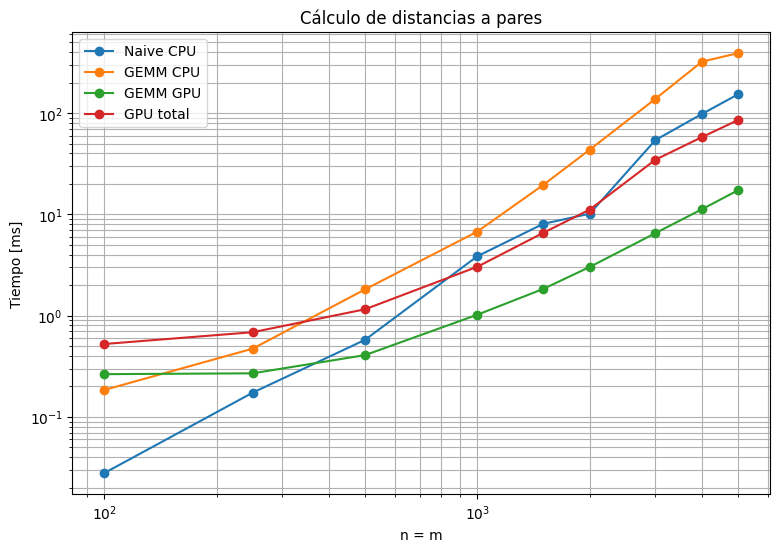

In [ ]:
plt.figure(figsize=(9, 6))

plt.loglog(
    results_df["n"],
    results_df["naive_cpu"] * 1000,
    "o-",
    label="Naive CPU"
)

plt.loglog(
    results_df["n"],
    results_df["gemm_cpu"] * 1000,
    "o-",
    label="GEMM CPU"
)

plt.loglog(
    results_df["n"],
    results_df["gemm_gpu"] * 1000,
    "o-",
    label="GEMM GPU"
)

plt.loglog(
    results_df["n"],
    results_df["gpu_total"] * 1000,
    "o-",
    label="GPU total"
)

plt.xlabel("n = m")
plt.ylabel("Tiempo [ms]")
plt.title("Cálculo de distancias a pares")
plt.grid(True, which="both")
plt.legend()

plt.show()

Veo que para n pequeño la CPU con numba gana con diferencia. Esto tiene sentido ya que se ahorra la inicialización de los kernels en la GPU y los tiempos de espera del bus para ir moviendo los datos entre CPU y GPU. En "GPU total" muestro que pasa si todo lo devuelvo a CPU como para que la máquina termine en un estado análogo, e incluso así gana a n alto. De todos modos no es necesario que todo vuelva a la CPU ya que las cuentas para las que las necesitamos las podemos hacer todas en GPU.

Por otro lado, GEMM CPU + numpy es consistentemente peor que la implementación directa en CPU usando Numba. Esto puede ser por lo que sea que haya de backend disponible en collab para gemm en cpu, tal vez no es demasiado bueno.

# EJERCICIO 1.3


Una onda plana es una de la forma $u_{inc} (r) = e^{ikz}$

con $k = \frac{2 \pi}{\lambda}$

La esfera tiene radio $a$ y queremos fijar planos de la forma $z = z_0$ y ver qué pasa en $x=y=0$

Parametrizamos la esfera como $r'(\theta, \phi) = (a \sin(\theta) \cos(\phi), a \sin(\theta) \sin(\phi), a \cos(\theta))$ con $\theta \in [0,\pi]$ y $\phi \in [0, 2 \pi)$

La luz viaja en el sentido de z positivo, choca con la esfera en z negativo. Como en la intersección con la esfera cumple $z = a \cos(\theta)$, tenemos que la zona iluminada es

$z < 0 \iff a \cos(\theta) < 0 \iff \theta \in (\frac{\pi}{2}, \pi], \phi$ libre

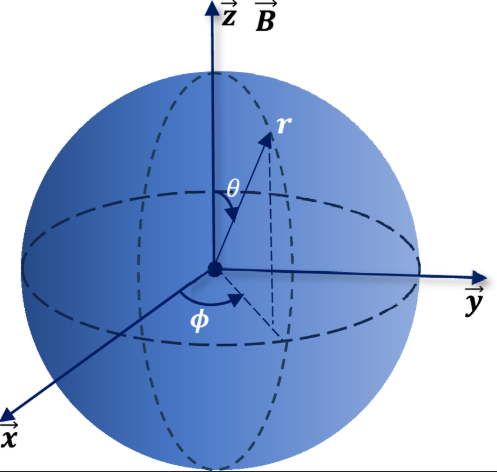

Ahora queremos el diferencial
$$
dS' = a^2 \sin(\theta) d\theta d\phi
$$

Por lo que estaremos integrando sobre $\theta$ entre $\pi / 2$ y $\pi$, y sobre $\phi$ entre 0 y $2\pi$

Ahora, sobre el plano en cuestión queremos estudiar cómo es afectado por la onda. Sabemos que los puntos son de la forma $(x, y, z_0)$ con $z_0$ el valor que le damos al plano (el corte en $z$)

Para cada punto de la esfera $r'$ queremos calcular como en el ej 1.4 la dist $R = |r-r'|$

Esto da lugar a:

$$
R(\theta, \phi, x, y, z_0) = \sqrt{(x - a \sin(theta))^2 + ...}
$$

Además el punto de Arago aparece en el $(0, 0, z_0)$ que sustituyendo en la ec. anterior queda en

$$
R(\theta, \phi, 0, 0, z_0) = \sqrt{ a^2 sin^2(\theta) \cos^2(\phi) + a^2 \sin^2(\theta) \sin^2(\phi) + (z_0 - a \cos(\theta))^2 }
$$

Sacando factor comun en los primeros dos términos, usando la identidad trigonometrica $sin^2+cos^2=1$ y despejando la raíz

$$
R^2 = a^2 + z_0^2 - 2az_0 \cos(\theta)
$$

(que no depende de $\phi$ por simetría axial...)

Para hacer la integral ahora podemos resolver la parte de $\phi$ por separado, que integra $2\pi$

Y queda integrar

$$
u_s(0,0,z_0) = 2 \pi a^2 \int^{\pi}_{\pi/2} Algo(0,0,z_0,\theta) \sin(\theta) d\theta)
$$

Esta función que da la aproximación de Kirchhoff no queda otra que sí usar cuadraturas

# Programación en GPU

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# Verificamos que la GPU esté activa
try:
    cp.cuda.Device(0).compute_capability
    print("GPU de CuPy detectada y lista para usar.")
except Exception as e:
    print("Error al cargar GPU")

GPU de CuPy detectada y lista para usar.


In [18]:
kernel_code_exact = r'''
#include <cuComplex.h>

extern "C" __global__
void kirchhoff_exact(
    const double* X, const double* Y,
    const double* xs, const double* ys, const double* zs,
    const double* nx, const double* ny, const double* nz,
    const double* weights,
    const double k, const double z_obs,
    const int Nsource, const int Nout,
    cuDoubleComplex* field
)
{
    // ========================================================================
    // FORMULACIÓN MATEMÁTICA UTILIZADA:
    // I = [ Phi_k * (du_i/dn) - u_i * (dPhi_k/dn) ]
    //
    // Agrupando todo y factorizando exp(i * k * (zs + R)) / (4 * PI):
    // I = exp(i * k * (zs + R)) / (4 * PI) * [ C_real + i * C_imag ]
    //
    // donde:
    // C_real = - dot / R^3
    // C_imag = (k * nz / R) + (k * dot / R^2)
    // ========================================================================

    const double PI = 3.1415926535897932384626433832795;
    const double INV4PI = 1.0 / (4.0 * PI);

    // Mando 1 thread por pixel del plano
    int p = blockDim.x * blockIdx.x + threadIdx.x;
    if (p >= Nout) return;

    double x = X[p];
    double y = Y[p];

    double real_sum = 0.0;
    double imag_sum = 0.0;

    // Acumulo sobre la cuadratura
    for (int s = 0; s < Nsource; s++)
    {
        // Vector distancia: r_obs - r_source
        double dx = x - xs[s];
        double dy = y - ys[s];
        double dz = z_obs - zs[s];

        double R2 = dx * dx + dy * dy + dz * dz;
        double R = sqrt(R2);

        // Precalcular inversas
        double invR  = 1.0 / R;
        double invR2 = invR * invR;
        double invR3 = invR2 * invR;

        // Producto punto: (r_obs - r_source) \cdot n
        double dot = dx * nx[s] + dy * ny[s] + dz * nz[s];

        // Fase total combinada: incidente + Green
        double phase = k * (zs[s] + R);
        double c  = cos(phase);
        double si = sin(phase);

        // Términos del corchete analítico [C_real + i * C_imag]
        double C_real = -dot * invR3;
        double C_imag = (k * nz[s] * invR) + (k * dot * invR2);

        // Multiplicación compleja
        double kernel_real = c * C_real - si * C_imag;
        double kernel_imag = si * C_real + c * C_imag;

        // Integración (Suma de Riemann)
        double factor = weights[s] * INV4PI;
        real_sum += kernel_real * factor;
        imag_sum += kernel_imag * factor;
    }

    field[p] = make_cuDoubleComplex(real_sum, imag_sum);
}
'''

# Compilar el kernel
kirchhoff_exact_kernel = cp.RawKernel(kernel_code_exact, "kirchhoff_exact")

# Función Wrapper en Python
def kirchhoff_plane_gpu_exact(
    X_gpu, Y_gpu, z_obs,
    x_source_gpu, y_source_gpu, z_source_gpu,
    nx_gpu, ny_gpu, nz_gpu, weights_gpu,
    k, threads=256
):
    Ny, Nx = X_gpu.shape
    Nout = Ny * Nx
    Nsource = x_source_gpu.size

    field = cp.empty(Nout, dtype=cp.complex128)
    blocks = (Nout + threads - 1) // threads

    kirchhoff_exact_kernel(
        (blocks,), (threads,),
        (
            X_gpu.ravel(), Y_gpu.ravel(),
            x_source_gpu, y_source_gpu, z_source_gpu,
            nx_gpu, ny_gpu, nz_gpu, weights_gpu,
            float(k), float(z_obs),
            Nsource, Nout, field
        )
    )
    return field.reshape(Ny, Nx)

In [19]:
def construir_geometria(radio, N_theta=200, N_phi=200, L_plano=6.0, N_xy_muestreo=400):
    # 1. Crear malla esférica (theta, phi)
    theta = np.linspace(0, np.pi, N_theta)
    phi = np.linspace(0, 2*np.pi, N_phi, endpoint=False)

    # Pesos de integración (regla de los trapecios para theta, rectangular para phi)
    dtheta = np.pi / (N_theta - 1)
    dphi = 2 * np.pi / N_phi
    w_theta = np.full(N_theta, dtheta)
    w_theta[0] /= 2.0
    w_theta[-1] /= 2.0
    w_phi = np.full(N_phi, dphi)

    # Convertir a matrices 2D (Meshgrid)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    W_theta_grid, W_phi_grid = np.meshgrid(w_theta, w_phi, indexing='ij')

    # 2. Coordenadas de la superficie de la esfera
    x_s = radio * np.sin(theta_grid) * np.cos(phi_grid)
    y_s = radio * np.sin(theta_grid) * np.sin(phi_grid)
    z_s = radio * np.cos(theta_grid)

    # 3. Normales exteriores
    nx_s = np.sin(theta_grid) * np.cos(phi_grid)
    ny_s = np.sin(theta_grid) * np.sin(phi_grid)
    nz_s = np.cos(theta_grid)

    # 4. Pesos de cuadratura dS = R^2 * sin(theta) * d_theta * d_phi
    weights_s = (radio**2) * np.sin(theta_grid) * W_theta_grid * W_phi_grid

    # 5. Filtrar solo la cara iluminada (onda incide en +z, choca donde normal apunta a -z)
    illuminated = nz_s < 0
    x_s = x_s[illuminated]
    y_s = y_s[illuminated]
    z_s = z_s[illuminated]
    nx_s = nx_s[illuminated]
    ny_s = ny_s[illuminated]
    nz_s = nz_s[illuminated]
    weights_s = weights_s[illuminated]

    # 6. Plano de observación
    x_values = np.linspace(-0.5 * L_plano, 0.5 * L_plano, N_xy_muestreo)
    y_values = np.linspace(-0.5 * L_plano, 0.5 * L_plano, N_xy_muestreo)
    X, Y = np.meshgrid(x_values, y_values)

    return x_s, y_s, z_s, nx_s, ny_s, nz_s, weights_s, X, Y

In [20]:
# ==========================================
# PARÁMETROS FÍSICOS
# ==========================================
longitud_onda = 1.0
k = 2.0 * np.pi / longitud_onda
a = 2.0 * longitud_onda     # Radio de la esfera
z0 = 4.0 * longitud_onda    # Distancia del plano de observación detrás de la esfera
L_plano = 10.0 * longitud_onda # Tamaño del plano de observación

# 1. Construir geometría
print("Construyendo geometría...")
(x_s, y_s, z_s, nx_s, ny_s, nz_s, weights_s, X, Y) = construir_geometria(
    radio=a, N_theta=300, N_phi=300, L_plano=L_plano, N_xy_muestreo=500
)

# 2. Enviar a GPU
print("Enviando datos a la GPU...")
X_gpu = cp.asarray(X, dtype=cp.float64)
Y_gpu = cp.asarray(Y, dtype=cp.float64)
x_source_gpu = cp.asarray(x_s.ravel(), dtype=cp.float64)
y_source_gpu = cp.asarray(y_s.ravel(), dtype=cp.float64)
z_source_gpu = cp.asarray(z_s.ravel(), dtype=cp.float64)
nx_gpu = cp.asarray(nx_s.ravel(), dtype=cp.float64)
ny_gpu = cp.asarray(ny_s.ravel(), dtype=cp.float64)
nz_gpu = cp.asarray(nz_s.ravel(), dtype=cp.float64)
weights_gpu = cp.asarray(weights_s.ravel(), dtype=cp.float64)

# 3. Ejecutar Kernel
print("Ejecutando Kernel en CUDA...")
campo_dispersado_gpu = kirchhoff_plane_gpu_exact(
    X_gpu, Y_gpu, z0,
    x_source_gpu, y_source_gpu, z_source_gpu,
    nx_gpu, ny_gpu, nz_gpu, weights_gpu,
    k
)

# 4. Traer resultado a CPU
campo_dispersado = cp.asnumpy(campo_dispersado_gpu)

# 5. Calcular Campo Total (Incidente + Dispersado)
# El campo incidente es una onda plana pura evaluada en el plano z = z0
campo_incidente = np.exp(1j * k * z0)
campo_total = campo_incidente - campo_dispersado
intensidad = np.abs(campo_total)**2

print("¡Cálculo finalizado con éxito!")

Construyendo geometría...
Enviando datos a la GPU...
Ejecutando Kernel en CUDA...
¡Cálculo finalizado con éxito!


<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3574/3662686866.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Patrón de Difracción en $z={z0/longitud_onda:.1f}\lambda$')
/tmp/ipykernel_3574/3662686866.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('x / $\lambda$')
/tmp/ipykernel_3574/3662686866.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('y / $\lambda$')
/tmp/ipykernel_3574/3662686866.py:28: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('x / $\lambda$')


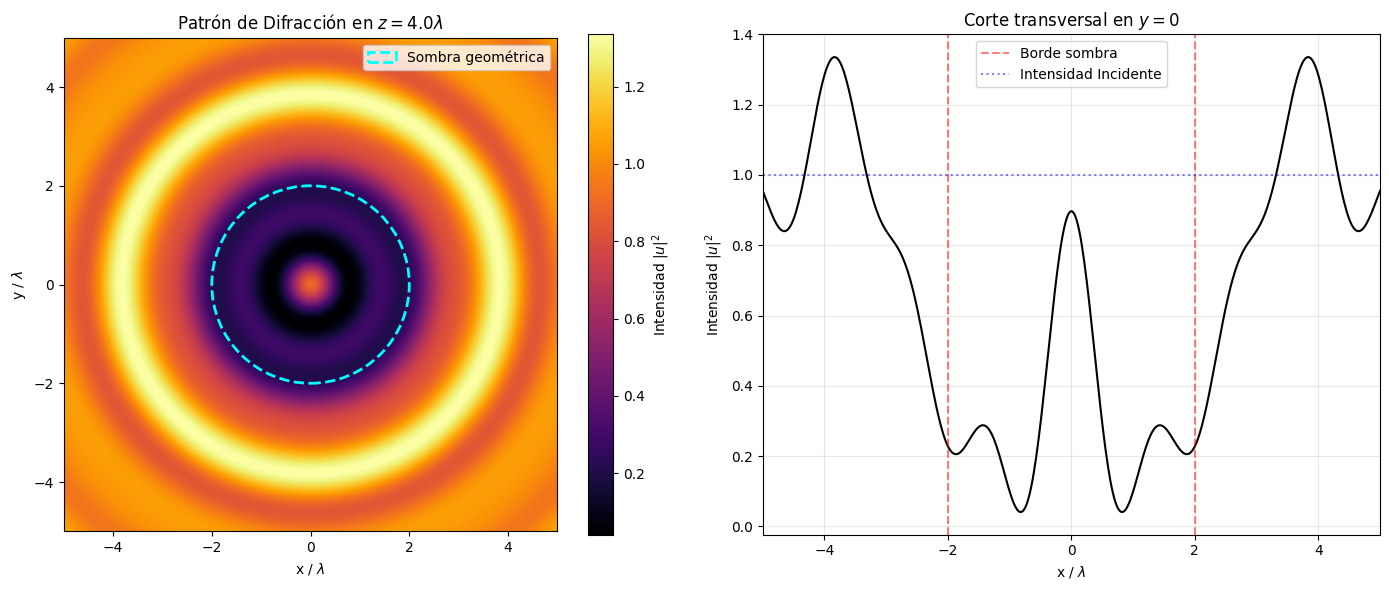

In [21]:
plt.figure(figsize=(14, 6))

# Subplot 1: Mapa 2D de Intensidad
plt.subplot(1, 2, 1)
extent = [-0.5*L_plano, 0.5*L_plano, -0.5*L_plano, 0.5*L_plano]
plt.imshow(intensidad, extent=extent, cmap='inferno', origin='lower')
# Dibujar el contorno geométrico de la esfera como referencia
circulo = plt.Circle((0, 0), a, color='cyan', fill=False, linestyle='--', linewidth=2, label='Sombra geométrica')
plt.gca().add_patch(circulo)
plt.colorbar(label='Intensidad $|u|^2$')
plt.title(f'Patrón de Difracción en $z={z0/longitud_onda:.1f}\lambda$')
plt.xlabel('x / $\lambda$')
plt.ylabel('y / $\lambda$')
plt.legend(loc='upper right')

# Subplot 2: Corte transversal en y = 0
plt.subplot(1, 2, 2)
# Encontrar el índice central (y=0)
indice_y0 = intensidad.shape[0] // 2
x_corte = X[indice_y0, :]
int_corte = intensidad[indice_y0, :]

plt.plot(x_corte, int_corte, color='black', linewidth=1.5)
plt.axvline(-a, color='red', linestyle='--', alpha=0.5, label='Borde sombra')
plt.axvline(a, color='red', linestyle='--', alpha=0.5)
plt.axhline(1.0, color='blue', linestyle=':', alpha=0.5, label='Intensidad Incidente')
plt.title('Corte transversal en $y=0$')
plt.xlabel('x / $\lambda$')
plt.ylabel('Intensidad $|u|^2$')
plt.xlim(-0.5*L_plano, 0.5*L_plano)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
!pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.2/237.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 27.1 MB/s eta 0:00:00


In [17]:
import numpy as np
import cupy as cp
import pyvista as pv
import ipywidgets as widgets

from PIL import Image
from IPython.display import display, clear_output
import time

# ============================================================
# 1. CONFIGURACIÓN INICIAL Y PARÁMETROS FIJOS
# ============================================================

pv.OFF_SCREEN = True

# Parámetros físicos base
wavelength = 1.0
k = 2.0 * np.pi / wavelength
a_base = 2.0 * wavelength
z0_base = 4.0 * wavelength

# Resolución fija solicitada
N_xy = 300
N_theta = 100
N_phi = 100

L_plano_visual = 6.0
N_plano_visual = N_xy

# Definir la geometría estática de la esfera y la cuadratura para N_theta x N_phi
theta = np.linspace(np.pi / 2.0, np.pi, N_theta)  # Cara frontal iluminada
phi = np.linspace(0, 2 * np.pi, N_phi, endpoint=False)

dtheta = (np.pi / 2.0) / (N_theta - 1)
dphi = 2 * np.pi / N_phi
w_theta = np.full(N_theta, dtheta)
w_theta[0] /= 2.0
w_theta[-1] /= 2.0
w_phi = np.full(N_phi, dphi)

theta_grid, phi_grid = np.meshgrid(theta, phi, indexing="ij")

# ============================================================
# 3. CONFIGURACIÓN VISUAL Y CÁMARA
# ============================================================

a_visual_inicial = float(a_base)
onda_z_visual = -2.5 * a_visual_inicial
onda_lateral_visual = 0.8 * a_visual_inicial
eje_inicio_visual = -3.0 * a_visual_inicial
referencia_size = 3.6

camera_scale = max(
    6.0 * a_visual_inicial,
    float(z0_base) * 1.15,
    L_plano_visual * 1.2
)

cam_x_inicial = 0.20
cam_y_inicial = -0.85
cam_z_inicial = 0.48

camera_initial_position = np.array([
    cam_x_inicial * camera_scale,
    cam_y_inicial * camera_scale,
    cam_z_inicial * camera_scale
])

camera_initial_focal = np.array([0.35 * camera_scale, 0.0, 0.0])
camera_direction = camera_initial_focal - camera_initial_position
camera_direction = camera_direction / np.linalg.norm(camera_direction)
camera_focal_distance = 10.0 * camera_scale


def transformar_visual(x, y, z):
    return z, x, y


def construir_esfera_visual(a_val):
    return (
        a_val * np.sin(theta_grid) * np.cos(phi_grid),
        a_val * np.sin(theta_grid) * np.sin(phi_grid),
        a_val * np.cos(theta_grid)
    )


def construir_plano_visual(L_visual, N_visual):
    x_values = np.linspace(-0.5 * L_visual, 0.5 * L_visual, N_visual)
    y_values = np.linspace(-0.5 * L_visual, 0.5 * L_visual, N_visual)
    return np.meshgrid(x_values, y_values)


# ============================================================
# 4. FUNCIÓN DE RENDERIZADO PYVISTA
# ============================================================

def crear_render(
    a_nuevo, z_nuevo,
    X_nuevo, Y_nuevo,
    x_s, y_s, z_s,
    intensity,
    cam_x, cam_y, cam_z,
    mostrar_cuadratura=False
):
    plotter = pv.Plotter(off_screen=True, window_size=(1200, 750))

    # Esfera
    sphere_x, sphere_y, sphere_z = construir_esfera_visual(a_nuevo)
    sx_v, sy_v, sz_v = transformar_visual(sphere_x, sphere_y, sphere_z)
    sphere_grid = pv.StructuredGrid(sx_v, sy_v, sz_v)
    plotter.add_mesh(sphere_grid, color="royalblue", opacity=0.55, smooth_shading=True, name="esfera")

    # Plano de observación
    plane_z = np.full_like(X_nuevo, z_nuevo, dtype=float)
    px_v, py_v, pz_v = transformar_visual(X_nuevo, Y_nuevo, plane_z)
    plane_grid = pv.StructuredGrid(px_v, py_v, pz_v)
    plane_grid["intensity"] = intensity.ravel(order="C")

    intensity_max = np.nanmax(intensity)
    if not np.isfinite(intensity_max) or intensity_max <= 0:
        intensity_max = 1.0

    plotter.add_mesh(
        plane_grid, scalars="intensity", cmap="inferno",
        clim=[0, intensity_max], opacity=0.95, smooth_shading=True,
        interpolate_before_map=True, show_scalar_bar=True,
        scalar_bar_args={"title": r"|u|²"}, name="plano"
    )

    # Borde del plano
    half = 0.5 * L_plano_visual
    corners = np.array([
        transformar_visual(-half, -half, z_nuevo),
        transformar_visual(half, -half, z_nuevo),
        transformar_visual(half, half, z_nuevo),
        transformar_visual(-half, half, z_nuevo),
        transformar_visual(-half, -half, z_nuevo)
    ])
    plotter.add_mesh(pv.lines_from_points(corners), color="white", line_width=2.5, name="borde_plano")

    # Cuadratura
    if mostrar_cuadratura:
        px, py, pz = transformar_visual(x_s, y_s, z_s)
        points = np.column_stack([px.ravel(), py.ravel(), pz.ravel()])
        plotter.add_mesh(pv.PolyData(points), color="white", point_size=3, render_points_as_spheres=True, opacity=0.5, name="cuadratura")

    # Onda plana (Flechas)
    n_arrows = 8
    arrow_xy = np.linspace(-onda_lateral_visual, onda_lateral_visual, n_arrows)
    arrow_x, arrow_y = np.meshgrid(arrow_xy, arrow_xy)
    ax_v, ay_v, az_v = transformar_visual(arrow_x.ravel(), arrow_y.ravel(), onda_z_visual * np.ones_like(arrow_x.ravel()))
    arrow_poly = pv.PolyData(np.column_stack([ax_v, ay_v, az_v]))
    vectors = np.zeros((len(arrow_poly.points), 3))
    vectors[:, 0] = 1.0
    arrow_poly["vectors"] = vectors
    plotter.add_mesh(arrow_poly.glyph(orient="vectors", scale=False, factor=0.22 * a_visual_inicial), color="gold", name="onda")

    # Referencia z=0 y Eje Z
    reference = pv.Plane(center=(0.0, 0.0, 0.0), direction=(1.0, 0.0, 0.0), i_size=referencia_size, j_size=referencia_size)
    plotter.add_mesh(reference, color="white", opacity=0.05, show_edges=True, edge_color="gray", name="z0")
    #plotter.add_mesh(pv.Line((eje_inicio_visual, 0, 0), (z_nuevo + 0.5 * a_visual_inicial, 0, 0)), color="black", line_width=2, name="eje_z")

    # Textos
    plotter.add_text("Difracción de Kirchhoff (GPU Exacta)", position="upper_left", font_size=17, color="black", name="titulo")
    plotter.add_text(f"a = {a_nuevo:.3f}\nz₀ = {z_nuevo:.3f}\nλ = {wavelength:.3f}", position="lower_left", font_size=13, color="black", name="parametros")

    # Cámara
    camera_position = np.array([cam_x * camera_scale, cam_y * camera_scale, cam_z * camera_scale])
    camera_focal_point = camera_position + camera_direction * camera_focal_distance
    plotter.camera_position = [tuple(camera_position), tuple(camera_focal_point), (0.0, 0.0, 1.0)]

    plotter.set_background("white")
    plotter.render()
    image = plotter.screenshot(return_img=True)
    plotter.close()
    return image


# ============================================================
# 5. WIDGETS DE INTERACCIÓN
# ============================================================

a_slider = widgets.FloatSlider(value=a_base, min=0.5 * a_base, max=2.0 * a_base, step=0.05 * a_base, description="Radio a", continuous_update=False)
z_slider = widgets.FloatSlider(value=z0_base, min=0.2 * a_base, max=6.0 * a_base, step=0.05 * a_base, description="Plano z₀", continuous_update=False)
cam_x_slider = widgets.FloatSlider(value=cam_x_inicial, min=-2.0, max=2.0, step=0.05, description="Cámara X", continuous_update=False)
cam_y_slider = widgets.FloatSlider(value=cam_y_inicial, min=-2.0, max=2.0, step=0.05, description="Cámara Y", continuous_update=False)
cam_z_slider = widgets.FloatSlider(value=cam_z_inicial, min=-2.0, max=2.0, step=0.05, description="Cámara Z", continuous_update=False)
points_checkbox = widgets.Checkbox(value=False, description="Mostrar cuadratura")

status = widgets.HTML(value="<b style='color:green'>Listo</b>")
output = widgets.Layout(width="1200px")
output_widget = widgets.Output(layout=output)

updating = False


# ============================================================
# 6. FUNCIÓN DE ACTUALIZACIÓN Y BENCHMARK DE TIEMPO
# ============================================================

def actualizar_visualizacion(change=None):
    global updating
    if updating:
        return
    updating = True

    try:
        t_total_inicio = time.perf_counter()

        a_nuevo = float(a_slider.value)
        z_nuevo = float(z_slider.value)
        cam_x = float(cam_x_slider.value)
        cam_y = float(cam_y_slider.value)
        cam_z = float(cam_z_slider.value)

        status.value = "<b style='color:orange'>Calculando en GPU...</b>"

        # 1. Construir plano visual con grilla fija N_xy = 100x100
        X_nuevo, Y_nuevo = construir_plano_visual(L_plano_visual, N_plano_visual)

        # 2. Construir geometría de la esfera con N_theta x N_phi (100x100)
        x_s = a_nuevo * np.sin(theta_grid) * np.cos(phi_grid)
        y_s = a_nuevo * np.sin(theta_grid) * np.sin(phi_grid)
        z_s = a_nuevo * np.cos(theta_grid)

        nx_s = np.sin(theta_grid) * np.cos(phi_grid)
        ny_s = np.sin(theta_grid) * np.sin(phi_grid)
        nz_s = np.cos(theta_grid)

        weights_s = (a_nuevo**2) * np.sin(theta_grid) * w_theta[:, None] * w_phi

        # 3. Transferir a GPU
        X_gpu = cp.asarray(X_nuevo, dtype=cp.float64)
        Y_gpu = cp.asarray(Y_nuevo, dtype=cp.float64)
        x_s_gpu = cp.asarray(x_s.ravel(), dtype=cp.float64)
        y_s_gpu = cp.asarray(y_s.ravel(), dtype=cp.float64)
        z_s_gpu = cp.asarray(z_s.ravel(), dtype=cp.float64)
        nx_s_gpu = cp.asarray(nx_s.ravel(), dtype=cp.float64)
        ny_s_gpu = cp.asarray(ny_s.ravel(), dtype=cp.float64)
        nz_s_gpu = cp.asarray(nz_s.ravel(), dtype=cp.float64)
        weights_s_gpu = cp.asarray(weights_s.ravel(), dtype=cp.float64)

        # 4. Ejecutar Kernel CUDA Exacto
        field_gpu = kirchhoff_plane_gpu_exact(
            X_gpu, Y_gpu, z_nuevo,
            x_s_gpu, y_s_gpu, z_s_gpu,
            nx_s_gpu, ny_s_gpu, nz_s_gpu,
            weights_s_gpu, k
        )

        # 5. Onda incidente y superposición (Principio de Babinet)
        u_incident = cp.exp(1j * k * z_nuevo)
        u_total = field_gpu.copy()
        shadow = (X_gpu**2 + Y_gpu**2) <= a_nuevo**2
        u_total[~shadow] += u_incident

        intensity = cp.asnumpy(cp.abs(u_total)**2)

        # 6. Renderizado PyVista
        image = crear_render(
            a_nuevo, z_nuevo,
            X_nuevo, Y_nuevo,
            x_s, y_s, z_s,
            intensity,
            cam_x, cam_y, cam_z,
            mostrar_cuadratura=points_checkbox.value
        )

        t_total = time.perf_counter() - t_total_inicio

        print("====================================")
        print("BENCHMARK PIPELINE (CUDA EXACTO)")
        print("====================================")
        print(f"N plano        = {N_plano_visual} x {N_plano_visual}")
        print(f"N cuadratura   = {x_s.size} ({N_theta} x {N_phi})")
        print(f"Tiempo total   = {t_total:.6f} s")

        with output_widget:
            clear_output(wait=True)
            display(Image.fromarray(image))

        status.value = "<b style='color:green'>Listo</b>"

    except Exception as e:
        status.value = f"<b style='color:red'>Error: {e}</b>"
        raise
    finally:
        updating = False


# ============================================================
# 7. REGISTRO DE OBSERVADORES Y EJECUCIÓN
# ============================================================

a_slider.observe(actualizar_visualizacion, names="value")
z_slider.observe(actualizar_visualizacion, names="value")
cam_x_slider.observe(actualizar_visualizacion, names="value")
cam_y_slider.observe(actualizar_visualizacion, names="value")
cam_z_slider.observe(actualizar_visualizacion, names="value")
points_checkbox.observe(actualizar_visualizacion, names="value")

display(widgets.VBox([
    a_slider, z_slider,
    widgets.HTML("<b>Posición de la cámara</b>"),
    cam_x_slider, cam_y_slider, cam_z_slider,
    points_checkbox, status
]))

display(output_widget)

# Render inicial
actualizar_visualizacion()

Output(layout=Layout(width='1200px'))

BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 2.014244 s
BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 1.185314 s
BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 1.036861 s
BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 1.399064 s
BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 1.148809 s
BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 1.051737 s
BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 1.470690 s
BENCHMARK PIPELINE (CUDA EXACTO)
N plano        = 300 x 300
N cuadratura   = 10000 (100 x 100)
Tiempo total   = 1.223660 s
BENCHMARK PIPELI